# Time series analysis aand preprocessingm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load and visualize time series data

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, index_col=0, parse_dates=True)
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<Axes: xlabel='Date'>

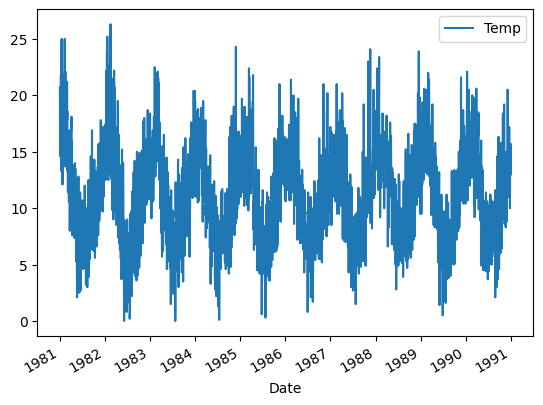

In [3]:
df.plot()

array([[<Axes: title={'center': 'Temp'}>]], dtype=object)

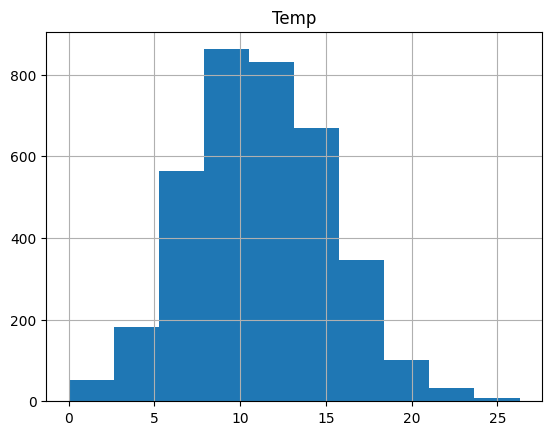

In [4]:
df.hist()

<Axes: ylabel='Density'>

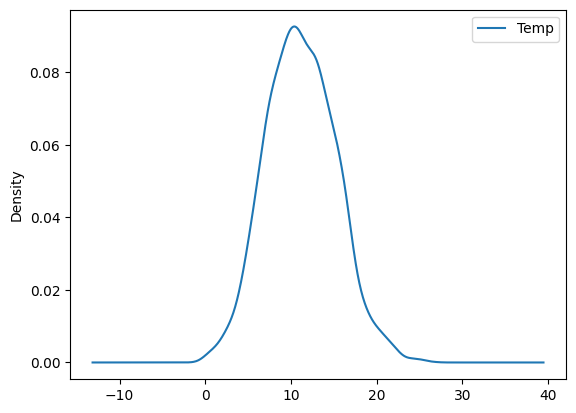

In [5]:
df.plot(kind='kde')

<Axes: >

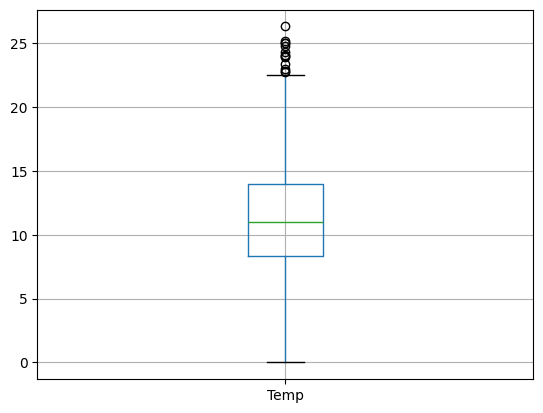

In [6]:
df.boxplot()

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

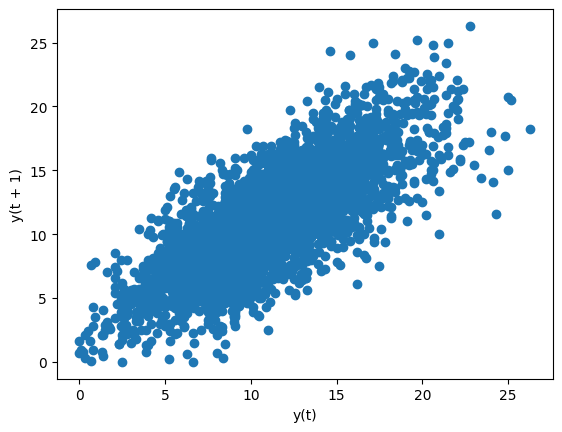

In [7]:
from pandas.plotting import lag_plot

lag_plot(df)

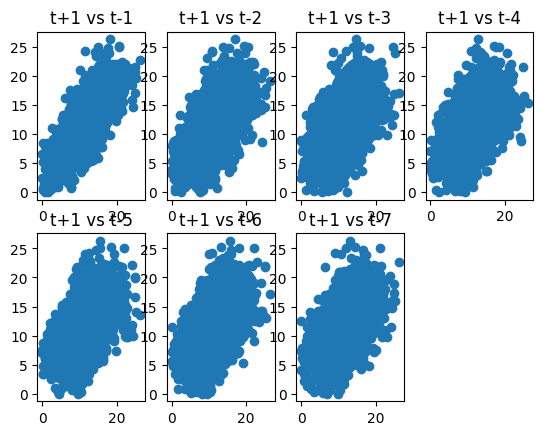

In [8]:
values = pd.DataFrame(df.values)
lags = 7
columns = [values]
for i in range(1,(lags + 1)):
    columns.append(values.shift(i))
dataframe = pd.concat(columns, axis=1)
columns = ['t+1']

for i in range(1,(lags + 1)):
    columns.append('t-' + str(i))
dataframe.columns = columns
for i in range(1,(lags + 1)):
    ax = plt.subplot(240 + i)
    ax.set_title('t+1 vs t-' + str(i))
    plt.scatter(x=dataframe['t+1'].values, y=dataframe['t-'+str(i)].values)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

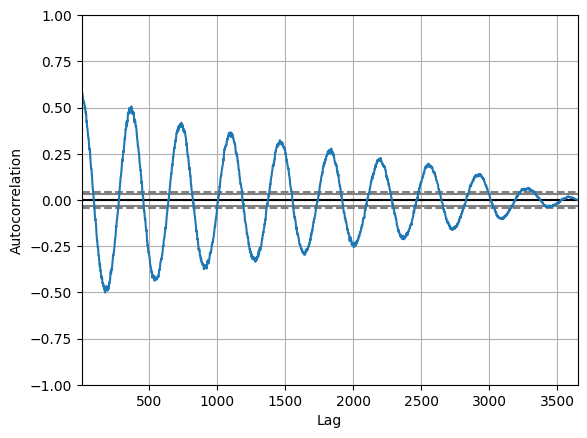

In [9]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df)

## Normalize and Standardize Time Series

### Normalization

Min-max (between 0 and 1)

In [10]:
from sklearn.preprocessing import MinMaxScaler

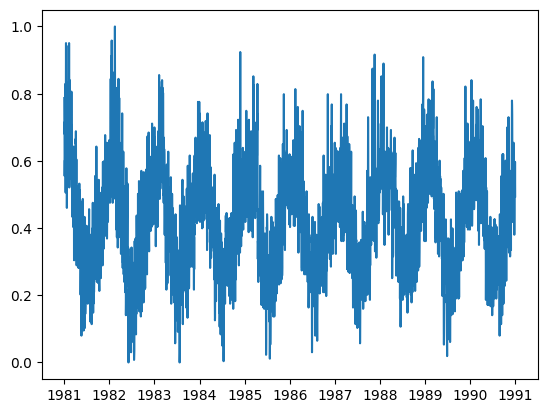

In [11]:
scaler = MinMaxScaler()
values = df.values
scaler.fit(values)
values_normalized = scaler.transform(values)
plt.plot(df.index, values_normalized)

### Standartizing

Mean = 0, std = 1

In [12]:
from sklearn.preprocessing import StandardScaler

(array([ 53., 181., 564., 862., 830., 670., 347., 102.,  32.,   9.]),
 array([-2.74551393, -2.0995253 , -1.45353667, -0.80754804, -0.1615594 ,
         0.48442923,  1.13041786,  1.77640649,  2.42239512,  3.06838375,
         3.71437239]),
 <BarContainer object of 10 artists>)

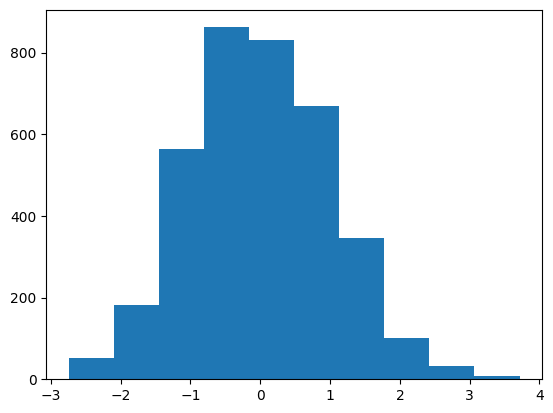

In [13]:
scaler = StandardScaler()
values = df.values
scaler.fit(values)
values_standardized = scaler.transform(values)
plt.hist(values_standardized)

## Basic Feature Engineering

Date and time

In [14]:
dataframe = df.copy()
dataframe['month'] = [dataframe.index[i].month for i in range(len(dataframe))]
dataframe['year'] = [dataframe.index[i].year for i in range(len(dataframe))]
dataframe['day'] = [dataframe.index[i].day for i in range(len(dataframe))]
dataframe.head()

,Temp,month,year,day
Date,,,,
1981-01-01,20.7,1,1981,1
1981-01-02,17.9,1,1981,2
1981-01-03,18.8,1,1981,3
1981-01-04,14.6,1,1981,4
1981-01-05,15.8,1,1981,5


Lag

In [15]:
lag = 1
dataframe['lag_'+str(lag)] = dataframe['Temp'].shift(lag)
dataframe.head()

,Temp,month,year,day,lag_1
Date,,,,,
1981-01-01,20.7,1,1981,1,NaN
1981-01-02,17.9,1,1981,2,20.7
1981-01-03,18.8,1,1981,3,17.9
1981-01-04,14.6,1,1981,4,18.8
1981-01-05,15.8,1,1981,5,14.6


Rolling

In [16]:
dataframe['mean'] = dataframe['Temp'].rolling(window=4).mean()
dataframe.head()

,Temp,month,year,day,lag_1,mean
Date,,,,,,
1981-01-01,20.7,1,1981,1,NaN,NaN
1981-01-02,17.9,1,1981,2,20.7,NaN
1981-01-03,18.8,1,1981,3,17.9,NaN
1981-01-04,14.6,1,1981,4,18.8,18.000
1981-01-05,15.8,1,1981,5,14.6,16.775


Expanding window

In [17]:
dataframe = df.copy()
window = dataframe.expanding()
dataframe = pd.concat([window.min(), window.mean(), window.max(), dataframe.shift(-1)], axis=1)
dataframe.columns = ['min', 'mean', 'max', 't+1']
dataframe.head(5)

,min,mean,max,t+1
Date,,,,
1981-01-01,20.7,20.700000,20.7,17.9
1981-01-02,17.9,19.300000,20.7,18.8
1981-01-03,17.9,19.133333,20.7,14.6
1981-01-04,14.6,18.000000,20.7,15.8
1981-01-05,14.6,17.560000,20.7,15.8


## Resampling

Upsample

In [18]:
dataframe = df.copy()
upsampled = dataframe.resample('5D').mean()
upsampled.head()

,Temp
Date,
1981-01-01,17.56
1981-01-06,18.16
1981-01-11,18.54
1981-01-16,19.86
1981-01-21,15.44


In [19]:
interpolated = upsampled.interpolate(method='linear')
interpolated.head()

,Temp
Date,
1981-01-01,17.56
1981-01-06,18.16
1981-01-11,18.54
1981-01-16,19.86
1981-01-21,15.44


## Removing a trand

C:\Users\Matebook 14S\AppData\Local\Temp\ipykernel_3852\1060676934.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url, index_col=0, parse_dates=True)


<Axes: xlabel='Month'>

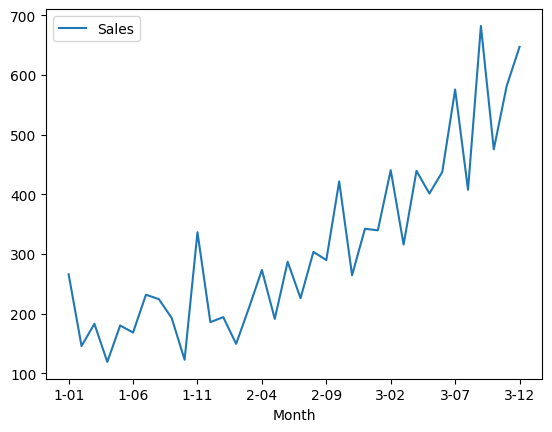

In [20]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv'
df = pd.read_csv(url, index_col=0, parse_dates=True)
df.plot()

By difference

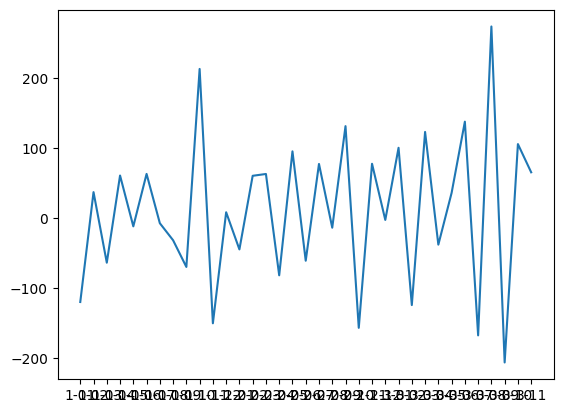

In [21]:
X = df.values
X_shifted = df.shift(-1).values
diff = (X_shifted - X).ravel()[:-1]
plt.plot(df.index[:-1], diff)

By model

In [22]:
from sklearn.linear_model import LinearRegression

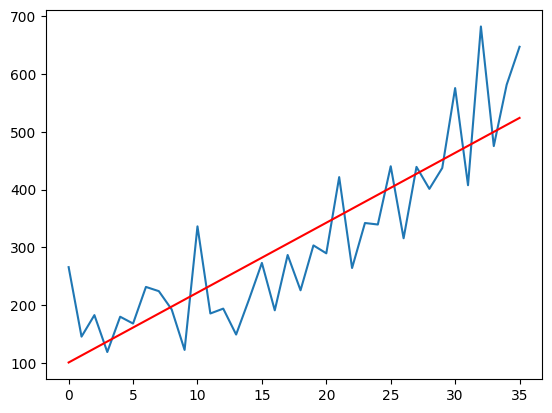

In [23]:
X = np.arange(0, len(df)).reshape(-1, 1)
y = df.values.ravel()
lin_reg = LinearRegression()
lin_reg.fit(X, y)
trand = lin_reg.predict(X)
plt.plot(X, y)
plt.plot(X, trand, color='red')

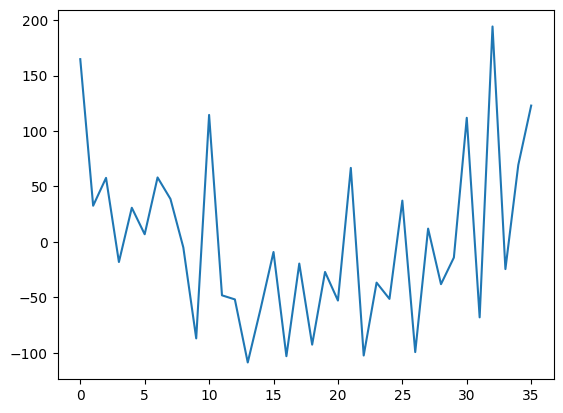

In [24]:
detrended = df.values.ravel() - trand
plt.plot(X, detrended)

## Remove seasonality

<Axes: xlabel='Date'>

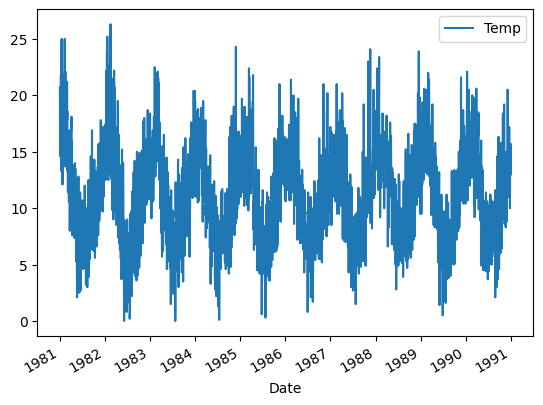

In [25]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, index_col=0, parse_dates=True)
df.plot()

Difference by season

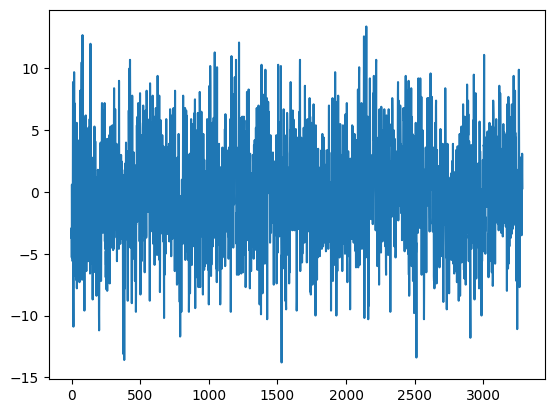

In [26]:
X = df.values
season = 365
diff = []
for i in range(season, len(X)):
    diff.append(X[i] - X[i-season])
plt.plot(diff)

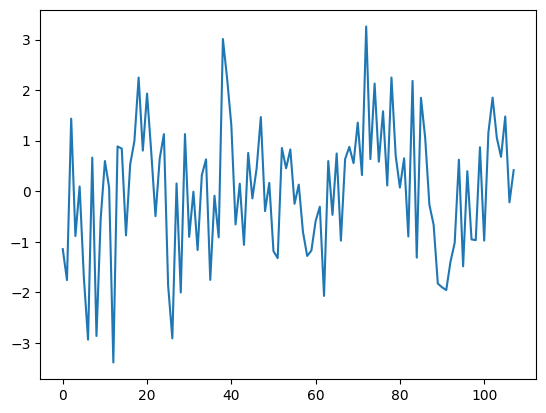

In [27]:
resample = df.resample('ME')
monthly_mean = resample.mean()
X = monthly_mean.values
season = 12
diff = []
for i in range(season, len(X)):
    diff.append(X[i] - X[i-season])
plt.plot(diff)

By sin model

In [28]:
from numpy import polyfit

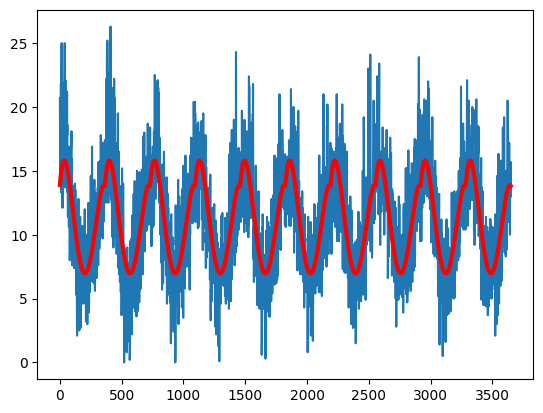

In [29]:
X = [i % 365 for i in range(len(df))]
y = df.values.ravel()
degree = 4
coef = polyfit(X, y, degree)
curve = []
for i in range(len(X)):
	value = coef[-1]
	for d in range(degree):
		value += X[i]**(degree-d) * coef[d]
	curve.append(value)
plt.plot(y)
plt.plot(curve, color='red', linewidth=3)

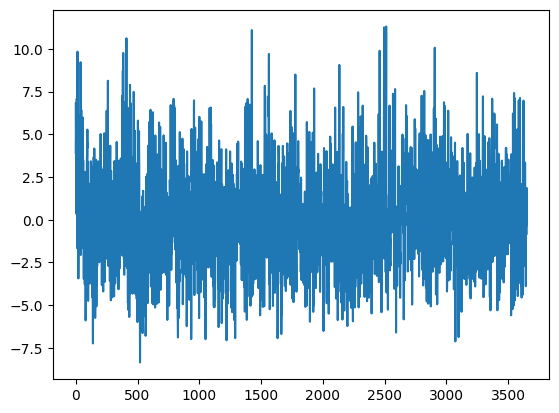

In [30]:
diff = y - curve
plt.plot(diff)

## Check stationarity

In [31]:
#stationary
url1 = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-total-female-births.csv'
#non-stationary
url2 = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df1 = pd.read_csv(url1, index_col=0, parse_dates=True)
df2 = pd.read_csv(url2, index_col=0, parse_dates=True)

<Axes: xlabel='Date'>

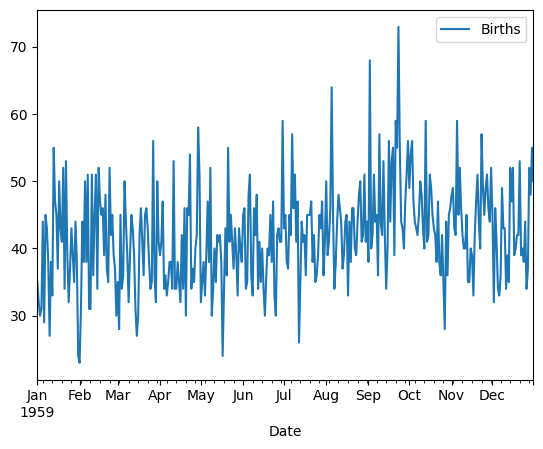

In [32]:
df1.plot()

<Axes: xlabel='Month'>

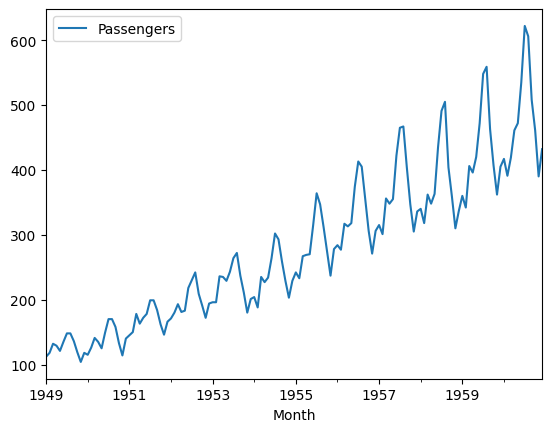

In [33]:
df2.plot()

Quick test: compare mean and variance on different time

In [34]:
split = len(df1) // 2
X1, X2 = df1.values[:split], df1.values[split:]
mean1, mean2 = X1.mean(), X2.mean()
var1, var2 = X1.var(), X2.var()
print(f"Mean: {mean1:.2f}, {mean2:.2f}")
print(f"Variance: {var1:.2f}, {var2:.2f}")

Mean: 39.76, 44.19
Variance: 49.21, 48.71


In [35]:
split = len(df2) // 2
X1, X2 = df2.values[:split], df2.values[split:]
mean1, mean2 = X1.mean(), X2.mean()
var1, var2 = X1.var(), X2.var()
print(f"Mean: {mean1:.2f}, {mean2:.2f}")
print(f"Variance: {var1:.2f}, {var2:.2f}")

Mean: 182.90, 377.69
Variance: 2244.09, 7367.96


Augmented Dickey-Fuller test

In [36]:
from statsmodels.tsa.stattools import adfuller

In [37]:
X = df1.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.808291
p-value: 0.000052
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


In [38]:
X = df2.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


## Trand ans season decomposition

<Axes: xlabel='Date'>

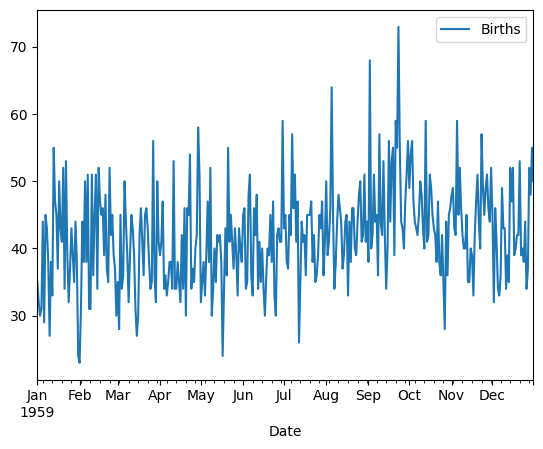

In [40]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url1, index_col=0, parse_dates=True)
df.plot()

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

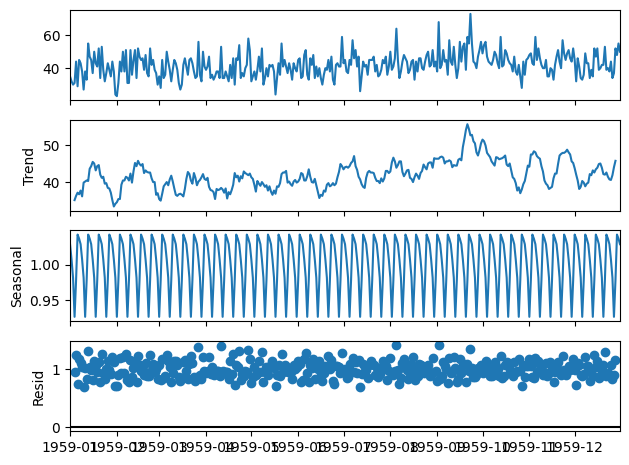

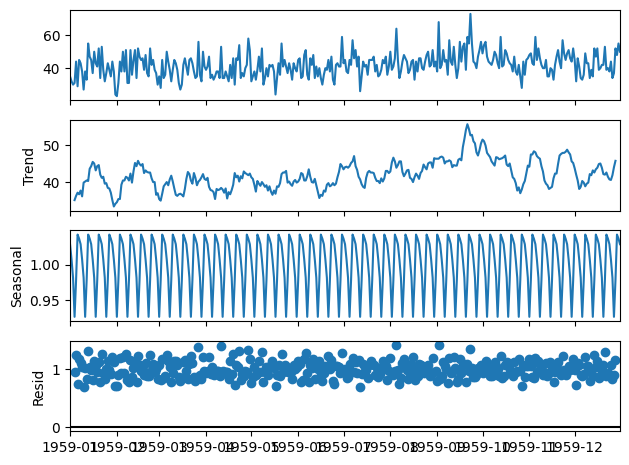

In [42]:
result = seasonal_decompose(df, model='multiplicative')
result.plot()